Import Config
---

In [ ]:
import sys
import os
import tifffile
import numpy as np
import cupy as cp
from pathlib import Path

sys.path.append('/home/cyf/wbi/Virginia/code_for_paper/wholistic_registration/src/wholistic_registration')
current_dir = os.path.dirname(os.path.abspath("__file__"))
root_dir = os.path.dirname(current_dir)
sys.path.append(root_dir)
from utils.IO import readND2Frame, readMeta
from utils.simulation import generateMotion_Biophysical
from utils import calFlow3d_Wei_v1, calFlowCrossResolution
from utils import visualization as vis
from utils import preprocess as prep
from utils import option

CuPy is available with CUDA - using GPU acceleration


generate 1 simulation

In [4]:
import sys
import os
import tifffile
import numpy as np
import cupy as cp
from pathlib import Path
HRdataPath = '/home/cyf/wbi/Virginia/raw_data/f2013/250705_f2013_ubi_gcamp7f_bactin_mcherry_6dpf_15846.nd2'
HRdata = readND2Frame(HRdataPath, 0, channel=1)
meta = readMeta(HRdataPath)
HRdata_xyz = HRdata.squeeze().transpose(2,1,0)
motion = generateMotion_Biophysical(
    HRdata_xyz.shape,
    art_R_xy=100,
    amp_xy=18,
    zRatio=3,
    use_incompressibility=True
)
def save_data(folder, motion, mov_raw, ref_raw, dat_mov):
    folder.mkdir(parents=True, exist_ok=True)
    tifffile.imwrite(folder / 'motion.tif', motion.astype(np.float32))
    tifffile.imwrite(folder / 'raw_mov.tif', mov_raw.astype(np.float32))
    tifffile.imwrite(folder / 'ref.tif', ref_raw.astype(np.float32))
    tifffile.imwrite(folder / 'mov.tif', dat_mov.astype(np.float32))
print(np.mean(np.abs(motion[...,2])))
mov_raw = calFlow3d_Wei_v1.correctMotion(HRdata_xyz, motion)
ref_raw = HRdata_xyz
dat_mov = mov_raw + np.random.randn(*HRdata_xyz.shape)*100

save_data(Path('/home/cyf/wbi/Virginia/code_for_paper/Fig2/2.1_simulation/pipeline_fig'), motion, mov_raw, ref_raw, dat_mov)

Z ratio is 3.0769230769230766
Data size is (1152, 1152, 19)
Total frames is 2
2.8162920727704073


Generate Simulation
---

In [6]:
import sys
import os
import tifffile
import numpy as np
import cupy as cp
from pathlib import Path
HRdataPath = '/home/cyf/wbi/Virginia/raw_data/f2013/250705_f2013_ubi_gcamp7f_bactin_mcherry_6dpf_15846.nd2'
HRdata = readND2Frame(HRdataPath, 0, channel=1)
meta = readMeta(HRdataPath)
HRdata_xyz = HRdata.squeeze().transpose(2,1,0)
print("HRdata shape:", HRdata_xyz.shape)
output_root = Path('/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420')
output_root.mkdir(parents=True, exist_ok=True)

# 组1：art_R sweep
art_R_ratios = [30,40,50,60,70,80,90,100,110,120]
art_R_ratio_z = 1 / 4
# 组2（稳定版）：形变强度 κ sweep
kappa_list = [0.05,0.06, 0.07,0.08, 0.09,0.10, 0.11,0.12, 0.13,0.14]
amp_ratio_z = 1 / 4
# 组3：noise sweep
noise_levels = [1.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0]

zRatio = 3.0769230769230766

# -----------------------------
# 保存函数
# -----------------------------
def save_data(folder, motion, mov_raw, ref_raw, dat_mov):
    folder.mkdir(parents=True, exist_ok=True)
    tifffile.imwrite(folder / 'motion.tif', motion.astype(np.float32))
    tifffile.imwrite(folder / 'raw_mov.tif', mov_raw.astype(np.float32))
    tifffile.imwrite(folder / 'ref.tif', ref_raw.astype(np.float32))
    tifffile.imwrite(folder / 'mov.tif', dat_mov.astype(np.float32))

# -----------------------------
# 主循环
# -----------------------------
num_seeds = 10
for seed_idx in range(1, num_seeds + 1):
    np.random.seed(seed_idx+20260119)
    repo_folder = output_root / 'repos' / f'rep{seed_idx:02d}'
    repo_folder.mkdir(parents=True, exist_ok=True)
    print(f"\n=== Seed {seed_idx} ===")
    # -------------------------
    # Group 1: art_R
    # -------------------------
    for idx, art_R_xy in enumerate(art_R_ratios):
        art_R_z = int(art_R_xy * art_R_ratio_z)
        folder = repo_folder / 'art_R' / f'{idx+1}'
        motion = generateMotion_Biophysical(
            HRdata_xyz.shape,
                art_R_xy=art_R_xy,
                amp_xy=8,
                zRatio=zRatio,
                use_incompressibility=True,
        )
        print(np.mean(np.abs(motion[...,2])))
        mov_raw = calFlow3d_Wei_v1.correctMotion(HRdata_xyz, motion)
        ref_raw = HRdata_xyz
        dat_mov = mov_raw + np.random.randn(*HRdata_xyz.shape)
        
        save_data(folder, motion, mov_raw, ref_raw, dat_mov)
    # -------------------------
    # Group 2: κ sweep（稳定）
    # -------------------------
    art_R_xy_fixed = 120
    art_R_z_fixed  = 6
    for idx, kappa in enumerate(kappa_list):
        amp_xy = kappa * art_R_xy_fixed
        amp_z  = min(amp_xy * amp_ratio_z, 0.3)
        folder = repo_folder / 'amp' / f'{idx+1}'
        motion = generateMotion_Biophysical(
            HRdata_xyz.shape,
            art_R_xy=art_R_xy_fixed,
            amp_xy=amp_xy,
            zRatio=zRatio,
            use_incompressibility=True
        )
        print(np.mean(np.abs(motion[...,2])))
        mov_raw = calFlow3d_Wei_v1.correctMotion(HRdata_xyz, motion)
        ref_raw = HRdata_xyz
        dat_mov = mov_raw + np.random.randn(*HRdata_xyz.shape)

        save_data(folder, motion, mov_raw, ref_raw, dat_mov)
    # -------------------------
    # Group 3: noise sweep
    # -------------------------
    for idx, noise_level in enumerate(noise_levels):
        folder = repo_folder / 'noise_level' / f'{idx+1}'

        motion = generateMotion_Biophysical(
            HRdata_xyz.shape,
            art_R_xy=120,
            amp_xy=8,
            zRatio=zRatio,
            use_incompressibility=True
        )
        print(np.mean(np.abs(motion[...,2])))
        mov_raw = calFlow3d_Wei_v1.correctMotion(HRdata_xyz, motion)
        ref_raw = HRdata_xyz
        dat_mov = mov_raw + np.random.randn(*HRdata_xyz.shape) * noise_level

        save_data(folder, motion, mov_raw, ref_raw, dat_mov)

print("\nAll experiments completed successfully.")


Z ratio is 3.0769230769230766
Data size is (1152, 1152, 19)
Total frames is 2
HRdata shape: (1152, 1152, 19)

=== Seed 1 ===
1.193659318305337
1.135313149528231
1.0476788519061317
1.1631169179012724
1.0899294437414213
1.133347488346724
1.0683846947673319
1.1325009260978627
1.064460824310605
1.21759795878242
0.9558857889957108
0.9701415124494425
1.3882960231536312
1.4419639301687366
1.6211128847471683
1.8816901260746361
2.028021077202215
2.207644584874507
2.382382856037902
2.112024879408697
1.0417037036567014
1.184853131391299
1.1116019362928231
1.145985544407406
1.059945489597982
1.1996364471333214
1.1646766773625565
1.2284679574407404
1.170440616733937

=== Seed 2 ===
1.1874818319282447
1.1998315078259243
1.153507920995366
1.1595996117956875
1.1999563658052008
1.1789295576996632
1.0929401183337566
1.1792818760825503
1.1360252130596553
1.2454514631948377
0.8526661879350454
0.9643856765132716
1.2732667507836604
1.5191496665273883
1.5541190566093042
1.5517327782451549
1.7028253530584405


In [8]:
import os
from pathlib import Path

import numpy as np
import tifffile

HRdataPath = '/home/cyf/wbi/Virginia/raw_data/f2013/250705_f2013_ubi_gcamp7f_bactin_mcherry_6dpf_15846.nd2'
HRdata = readND2Frame(HRdataPath, 0, channel=1)
meta = readMeta(HRdataPath)

# 原代码里是转成 (Z, Y, X)
ref_raw = HRdata.squeeze().transpose(2, 1, 0).astype(np.float32)
print("Reference shape (Z, Y, X):", ref_raw.shape)

# =========================
# 2. 输出目录
# =========================
output_root = Path('/home/cyf/wbi/Virginia/code_for_paper/data/random_sparse_stack_datas_0423')
output_root.mkdir(parents=True, exist_ok=True)

# =========================
# 3. 参数范围（沿用你给的范围）
# =========================
art_R_candidates = [30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
kappa_candidates = [0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14]
noise_candidates = [1.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0]

zRatio = 3.0769230769230766
art_R_ratio_z = 1 / 4
amp_ratio_z = 1 / 4

# 你要求 clip 的 slice
slice_idx = [2, 10, 18]

# 组2里原来的逻辑：amp_xy = kappa * art_R_xy_fixed
# 这里如果 art_R 是任意选的，那 amp 也跟当前 art_R 走更自然
# 即：amp_xy = kappa * art_R_xy
# 这样每个样本都有自己独立的一组 art_R / amp / noise

# =========================
# 4. 工具函数
# =========================
def sample_one_parameter_set(rng):
    """
    随机采样一组参数
    """
    art_R_xy = int(rng.choice(art_R_candidates))
    art_R_z = max(1, int(round(art_R_xy * art_R_ratio_z)))

    kappa = float(rng.choice(kappa_candidates))
    amp_xy = float(kappa * art_R_xy)
    amp_z = float(min(amp_xy * amp_ratio_z, 0.3))

    noise_level = float(rng.choice(noise_candidates))

    return {
        "art_R_xy": art_R_xy,
        "art_R_z": art_R_z,
        "kappa": kappa,
        "amp_xy": amp_xy,
        "amp_z": amp_z,
        "noise_level": noise_level,
    }


def generate_one_sample(ref_raw, params, zRatio):
    """
    生成一个样本：
    1) motion
    2) 变形
    3) 加噪
    4) 取指定 slices
    """
    motion = generateMotion_Biophysical(
        ref_raw.shape,
        art_R_xy=params["art_R_xy"],
        amp_xy=params["amp_xy"],
        zRatio=zRatio,
        use_incompressibility=True,
    )

    mov_raw = calFlow3d_Wei_v1.correctMotion(ref_raw, motion).astype(np.float32)

    # 加噪后的 moving
    dat_mov = mov_raw + np.random.randn(*ref_raw.shape).astype(np.float32) * params["noise_level"]
    dat_mov = dat_mov.astype(np.float32)

    # 截取 sparse slices
    sparse_mov = dat_mov.astype(np.float32)

    return sparse_mov, motion


def save_npz(sample_path, sparse_mov, params):
    """
    每个 npz 只保存：
    - 变形后的 sparse 图像
    - 参数
    """
    np.savez_compressed(
        sample_path,
        mov=sparse_mov,                     # shape: (len(slice_idx), Y, X)
        slice_idx=np.array(slice_idx, dtype=np.int32),

        art_R_xy=np.int32(params["art_R_xy"]),
        art_R_z=np.int32(params["art_R_z"]),
        kappa=np.float32(params["kappa"]),
        amp_xy=np.float32(params["amp_xy"]),
        amp_z=np.float32(params["amp_z"]),
        noise_level=np.float32(params["noise_level"]),
        zRatio=np.float32(zRatio),
    )


# =========================
# 5. 主循环
# =========================
num_samples = 300
base_seed = 20260423

rng = np.random.default_rng(base_seed)

for sample_id in range(num_samples):
    params = sample_one_parameter_set(rng)

    sparse_mov, motion = generate_one_sample(ref_raw, params, zRatio)

    sample_name = f"sample_{sample_id:06d}.npz"
    sample_path = output_root / sample_name
    save_npz(sample_path, sparse_mov, params)

    if sample_id % 50 == 0:
        mean_abs_uz = float(np.mean(np.abs(motion[..., 2]))) if motion.shape[-1] >= 3 else np.nan
        print(
            f"[{sample_id:06d}/{num_samples}] saved {sample_name} | "
            f"art_R_xy={params['art_R_xy']}, "
            f"amp_xy={params['amp_xy']:.3f}, "
            f"noise={params['noise_level']:.3f}, "
            f"mean|Uz|={mean_abs_uz:.6f}"
        )

print(f"\nAll done. Saved {num_samples} samples to:\n{output_root}")

Z ratio is 3.0769230769230766
Data size is (1152, 1152, 19)
Total frames is 2
Reference shape (Z, Y, X): (1152, 1152, 19)
[000000/300] saved sample_000000.npz | art_R_xy=100, amp_xy=12.000, noise=15.000, mean|Uz|=1.746751
[000050/300] saved sample_000050.npz | art_R_xy=60, amp_xy=7.200, noise=18.000, mean|Uz|=1.114751
[000100/300] saved sample_000100.npz | art_R_xy=30, amp_xy=1.800, noise=21.000, mean|Uz|=0.268364
[000150/300] saved sample_000150.npz | art_R_xy=40, amp_xy=4.000, noise=3.000, mean|Uz|=0.581284
[000200/300] saved sample_000200.npz | art_R_xy=70, amp_xy=5.600, noise=18.000, mean|Uz|=0.862323
[000250/300] saved sample_000250.npz | art_R_xy=40, amp_xy=5.600, noise=9.000, mean|Uz|=0.810635

All done. Saved 300 samples to:
/home/cyf/wbi/Virginia/code_for_paper/data/random_sparse_stack_datas_0423


Run Simulation
---

In [2]:
import os
from pathlib import Path
import numpy as np
import tifffile
import matplotlib.pyplot as plt
import sys


root_dir = Path('/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos')
# root_dir = Path('/home/cyf/wbi/Virginia/code/src/wholistic_registration/exp/simulation/repos')
zslices = [2, 10, 18]  # 选择 z slice
output_file = root_dir / 'MSE_summary.npy'

experiment_groups = ['art_R', 'amp', 'noise_level']  # 对应三组实验
results = {}  # 保存 MSE
results = {group: {} for group in experiment_groups}
repo_dirs = sorted([d for d in root_dir.iterdir() if d.is_dir() and d.name.startswith('rep')])
num_repos = len(repo_dirs)
print(f"Found {num_repos} repos: {[d.name for d in repo_dirs]}")
'''
for repo_idx, repo_dir in enumerate(repo_dirs):
    print(f"\n=== Processing Repo {repo_dir.name} ({repo_idx+1}/{num_repos}) ===")
    for group in experiment_groups:
        group_dir = repo_dir / group
        if not group_dir.exists():
            print(f"Warning: {group_dir} not exist, skipping")
            continue
        for subfolder in sorted(group_dir.iterdir(), key=lambda x: int(x.name)):
            if not subfolder.is_dir():
                continue
            exp_level = subfolder.name
            print(f"  Processing {group}/{exp_level}")
            ref_path = subfolder / 'ref.tif'
            mov_path = subfolder / 'mov.tif'  # raw_mov 文件名固定
            ref_data = tifffile.imread(ref_path)[..., 2:19].transpose(1,0,2)
            move_data = tifffile.imread(mov_path)[..., zslices].transpose(1,0,2)
            ref_data_clip = ref_data[:,:,[0,8,16]]
            
            # -----------------------------
            # option 配置（固定）
            # -----------------------------
            option['zRatio'] = 3.0769230769230766 * 8
            option['zRatio_HR'] = 3.0769230769230766
            option['layer'] = 1
            option['iter'] = 10
            option['smoothPenalty_raw'] = 0.03
            option['mask_ref'] = np.zeros(ref_data.shape, dtype=np.bool_)
            option['mask_mov'] = np.zeros(move_data.shape, dtype=np.bool_)

            Pnltfactor = prep.getSmPnltNormFctr(ref_data, option)
            smoothPenalty = Pnltfactor * option['smoothPenalty_raw']
            option['smoothPenalty'] = smoothPenalty
            option['movRange'] = 10

            # -----------------------------
            # 运行 warp 方法
            # -----------------------------
            motion_warp, _, _, _, data_mov_corrected = calFlow3d_Wei_v1.getMotion(ref_data_clip, move_data, option, verbose=False)
            mse_warp = np.mean((data_mov_corrected - move_data)[10:-10,10:-10,:]**2)

            # -----------------------------
            # 运行 map 方法
            # -----------------------------
            phase_map, motion_map, data_mov_mapped = calFlowCrossResolution.getMotion_v0113(move_data, ref_data, option, verbose=False)
            mse_map = np.mean((data_mov_mapped.get() - move_data)**2)

            print(f"    MSE warp: {mse_warp:.4f}, MSE map: {mse_map:.4f}")

            # 存储结果
            if exp_level not in results[group]:
                results[group][exp_level] = {
                    'mse_warp': [],
                    'mse_map': []
                }
            results[group][exp_level]['mse_warp'].append(mse_warp)
            results[group][exp_level]['mse_map'].append(mse_map)

# 计算平均值和标准差
processed_results = {}
for group in experiment_groups:
    if group not in results or not results[group]:
        continue
    
    # 按实验级别排序
    sorted_exp_levels = sorted(results[group].keys(),key=int)
    
    # 计算每个实验级别的平均值和标准差
    avg_mse_warp = []
    std_mse_warp = []
    avg_mse_map = []
    std_mse_map = []
    
    for exp_level in sorted_exp_levels:
        # warp方法
        warp_values = results[group][exp_level]['mse_warp']
        avg_mse_warp.append(np.mean(warp_values))
        std_mse_warp.append(np.std(warp_values))
        
        # map方法
        map_values = results[group][exp_level]['mse_map']
        avg_mse_map.append(np.mean(map_values))
        std_mse_map.append(np.std(map_values))
    
    processed_results[group] = {
        'labels': sorted_exp_levels,
        'avg_mse_warp': avg_mse_warp,
        'std_mse_warp': std_mse_warp,
        'avg_mse_map': avg_mse_map,
        'std_mse_map': std_mse_map
    }

# 保存 MSE 数据
output_dir = output_file.parent
output_dir.mkdir(parents=True, exist_ok=True)
np.save(output_file, processed_results)
print(f"Saved processed MSE summary to {output_file}")

# -----------------------------# 绘制曲线图# -----------------------------# 创建包含3个子图的大图（1行3列）
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# 为每种方法分配固定的颜色
method_colors = {
    'Warping': 'blue',  # warp方法用蓝色
    'Mapping': 'red'    # map方法用红色
}

# 子图标题映射
group_titles = {
    'art_R': 'Artificial Resolution',
    'amp': 'Amplitude Variation',
    'noise_level': 'Noise Level'
}

# 在每个子图中绘制对应实验组的结果
for idx, group in enumerate(experiment_groups):
    if group not in processed_results:
        continue  # 如果该组没有结果，跳过
        
    ax = axes[idx]
    labels = processed_results[group]['labels']
    x = np.arange(len(labels))
    
    # warp方法 - 绘制平均曲线和误差带
    avg_warp = processed_results[group]['avg_mse_warp']
    std_warp = processed_results[group]['std_mse_warp']
    ax.plot(x, avg_warp, '-o', color=method_colors['Warping'], label='warp Method')
    ax.fill_between(x, np.array(avg_warp) - np.array(std_warp), np.array(avg_warp) + np.array(std_warp), 
                    color=method_colors['Warping'], alpha=0.2, label='Warping Error Band')
    
    # map方法 - 绘制平均曲线和误差带
    avg_map = processed_results[group]['avg_mse_map']
    std_map = processed_results[group]['std_mse_map']
    ax.plot(x, avg_map, '--s', color=method_colors['Mapping'], label='Mapping Method')
    ax.fill_between(x, np.array(avg_map) - np.array(std_map), np.array(avg_map) + np.array(std_map), 
                    color=method_colors['Mapping'], alpha=0.2, label='Mapping Error Band')
    
    # 设置子图标题和标签
    ax.set_title(group_titles[group])
    ax.set_xlabel('Experiment Level')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend()

# 设置共用的y轴标签
axes[0].set_ylabel('MSE (Average ± Std)')

# 设置大图标题
fig.suptitle('Comparison of warp vs map Methods Across 3 Experiment Groups (10 Repos Average)', fontsize=16)

plt.tight_layout()
plt.subplots_adjust(top=0.85)  # 调整顶部空间以容纳大图标题
plt.show()

# 保存绘制的图形
graph_path = output_dir / 'mse_comparison_avg.png'
plt.savefig(graph_path, dpi=300, bbox_inches='tight')
print(f"Graph saved to {graph_path}")
'''

Found 10 repos: ['rep01', 'rep02', 'rep03', 'rep04', 'rep05', 'rep06', 'rep07', 'rep08', 'rep09', 'rep10']


'\nfor repo_idx, repo_dir in enumerate(repo_dirs):\n    print(f"\n=== Processing Repo {repo_dir.name} ({repo_idx+1}/{num_repos}) ===")\n    for group in experiment_groups:\n        group_dir = repo_dir / group\n        if not group_dir.exists():\n            print(f"Warning: {group_dir} not exist, skipping")\n            continue\n        for subfolder in sorted(group_dir.iterdir(), key=lambda x: int(x.name)):\n            if not subfolder.is_dir():\n                continue\n            exp_level = subfolder.name\n            print(f"  Processing {group}/{exp_level}")\n            ref_path = subfolder / \'ref.tif\'\n            mov_path = subfolder / \'mov.tif\'  # raw_mov 文件名固定\n            ref_data = tifffile.imread(ref_path)[..., 2:19].transpose(1,0,2)\n            move_data = tifffile.imread(mov_path)[..., zslices].transpose(1,0,2)\n            ref_data_clip = ref_data[:,:,[0,8,16]]\n            \n            # -----------------------------\n            # option 配置（固定）\n          

RAW WBI & Cross WBI

In [3]:
from importlib import reload
from utils import visualization
from utils import simulation
reload(simulation)
reload(calFlow3d_Wei_v1)
import cupy as cp
cp.cuda.Device(1).use()
for repo_idx, repo_dir in enumerate(repo_dirs):
    print(f"\n=== Processing Repo {repo_dir.name} ({repo_idx+1}/{num_repos}) ===")

    for group in experiment_groups:
        group_dir = repo_dir / group
        if not group_dir.exists():
            print(f"Warning: {group_dir} not exist, skipping")
            continue
        for subfolder in sorted(group_dir.iterdir(), key=lambda x: int(x.name)):
            if not subfolder.is_dir():
                continue
            exp_level = subfolder.name
            print(f"  Processing {group}/{exp_level}")
            ref_path = subfolder / 'ref.tif'
            mov_path = subfolder / 'mov.tif'
            motion_path = subfolder / 'motion.tif'
            if not ref_path.exists() or not mov_path.exists():
                print(f"    Missing file, skipping")
                continue
            ref_data = tifffile.imread(ref_path)[..., 2:19]
            move_data = tifffile.imread(mov_path)[..., zslices]
            full_motion=tifffile.imread(motion_path)
            motion_data = tifffile.imread(motion_path)[:,:,zslices,:]
            # print(np.mean(motion_data[:,:,:,2]**2))
            # print(np.mean(motion_data[:,:,:,0]**2))
            # print(np.mean(motion_data[:,:,:,1]**2))
            ref_data_clip = ref_data[:, :, [0,8,16]]
            option['zRatio'] = 3.0769230769230766 * 8
            option['zRatio_HR'] = 3.0769230769230766
            option['layer'] = 3
            option['iter'] = 10
            option['r']=5
            option['smoothPenalty_raw'] = 0.03
            option['mask_ref'] = np.zeros(ref_data.shape, dtype=np.bool_)
            option['mask_mov'] = np.zeros(move_data.shape, dtype=np.bool_)
            Pnltfactor = prep.getSmPnltNormFctr(ref_data, option)
            option['smoothPenalty'] = Pnltfactor * option['smoothPenalty_raw']
            option['movRange'] = 10
            option['wrong_region_enable']=False
            # try:
            motion_warp, _, _, _, data_mov_corrected = calFlow3d_Wei_v1.getMotion(
                ref_data_clip, move_data, option, verbose=False
            )
            # motion_mse_warp = np.mean((motion_warp - motion_data)[50:-50,50:-50,:,:] ** 2)
            # intensity_mse_warp = np.mean((data_mov_corrected.get() - move_data)[50:-50,50:-50,:] ** 2)

            phase_map, motion_map, data_mov_mapped = calFlowCrossResolution.getMotion_v2(
                move_data, ref_data, option, verbose=False
            )
            # motion_mse_map = np.mean((motion_map - motion_data)[50:-50,50:-50,:,:] ** 2)
            # intensity_mse_map = np.mean((data_mov_mapped - move_data)[50:-50,50:-50,:] ** 2)

            
            ##############################################################################################
            ## baseline
            crop = 50
            z_ratio_eval = option['zRatio_HR']  # 或者你最终想用于物理误差的那个 zRatio

            ref_eval = simulation.crop_valid(ref_data_clip, crop=crop)
            mov_eval = simulation.crop_valid(move_data, crop=crop)
            gt_motion_eval = simulation.crop_valid(motion_data, crop=crop)

            raw_intensity_mse = simulation.compute_intensity_mse(ref_eval, mov_eval)
            raw_intensity_rmse = simulation.compute_intensity_rmse(ref_eval, mov_eval)
            raw_intensity_ssim = simulation.compute_volume_ssim(ref_eval, mov_eval)


            ## warping method
            motion_warp_eval = simulation.crop_valid(motion_warp, crop=crop)
            data_mov_corrected_np = data_mov_corrected.get()
            warp_img_eval = simulation.crop_valid(data_mov_corrected_np, crop=crop)

            warp_intensity_mse = simulation.compute_intensity_mse(warp_img_eval, mov_eval)
            warp_intensity_rmse = simulation.compute_intensity_rmse(warp_img_eval, mov_eval)
            warp_intensity_ssim = simulation.compute_volume_ssim(warp_img_eval, mov_eval)

            warp_motion_metrics = simulation.compute_motion_metrics(
                motion_warp_eval,
                gt_motion_eval,
                z_ratio=z_ratio_eval,
                use_z=True
            )


            ## mapping method
            motion_map_eval = simulation.crop_valid(motion_map, crop=crop)
            map_img_eval = simulation.crop_valid(data_mov_mapped, crop=crop)

            map_intensity_mse = simulation.compute_intensity_mse(map_img_eval, mov_eval)
            map_intensity_rmse = simulation.compute_intensity_rmse(map_img_eval, mov_eval)
            map_intensity_ssim = simulation.compute_volume_ssim(map_img_eval, mov_eval)

            map_motion_metrics = simulation.compute_motion_metrics(
                motion_map_eval,
                gt_motion_eval,
                z_ratio=z_ratio_eval,
                use_z=True   # 如果你暂时只想比较xy，就改成 False
            )



            # print(f"[Intensity]  MSE raw:{np.mean((move_data - ref_data_clip)[50:-50,50:-50,:] ** 2):.4f}, MSE warp: {intensity_mse_warp:.4f}, MSE map: {intensity_mse_map:.4f}")
            # print(f"[Motion]   MSE raw:{np.mean(motion_data[50:-50,50:-50,:,:] ** 2):.4f}, MSE warp: {motion_mse_warp:.4f}, MSE map: {motion_mse_map:.4f}")

            print(
                f"[Intensity] "
                f"Raw MSE: {raw_intensity_mse:.4f}, RMSE: {raw_intensity_rmse:.4f}, SSIM: {raw_intensity_ssim:.4f} | "
                f"Warp MSE: {warp_intensity_mse:.4f}, RMSE: {warp_intensity_rmse:.4f}, SSIM: {warp_intensity_ssim:.4f} | "
                f"Map MSE: {map_intensity_mse:.4f}, RMSE: {map_intensity_rmse:.4f}, SSIM: {map_intensity_ssim:.4f}"
            )

            print(
                f"[Motion XY] "
                f"Warp EPE_xy: {warp_motion_metrics['motion_epe_xy_mean']:.4f}, "
                f"RMSE_xy: {warp_motion_metrics['motion_rmse_xy']:.4f} | "
                f"Map EPE_xy: {map_motion_metrics['motion_epe_xy_mean']:.4f}, "
                f"RMSE_xy: {map_motion_metrics['motion_rmse_xy']:.4f}"
            )

            if 'motion_epe_phys_mean' in warp_motion_metrics and 'motion_epe_phys_mean' in map_motion_metrics:
                print(
                    f"[Motion 3D/Phys] "
                    f"Warp EPE_phys: {warp_motion_metrics['motion_epe_phys_mean']:.4f}, "
                    f"RMSE_z: {warp_motion_metrics['motion_rmse_z']:.4f} | "
                    f"Map EPE_phys: {map_motion_metrics['motion_epe_phys_mean']:.4f}, "
                    f"RMSE_z: {map_motion_metrics['motion_rmse_z']:.4f}"
                )

            if exp_level not in results[group]:
                results[group][exp_level] = {
                    # baseline
                    'raw_intensity_mse': [],
                    'raw_intensity_rmse': [],
                    'raw_intensity_ssim': [],

                    # warp image metrics
                    'warp_intensity_mse': [],
                    'warp_intensity_rmse': [],
                    'warp_intensity_ssim': [],

                    # map image metrics
                    'map_intensity_mse': [],
                    'map_intensity_rmse': [],
                    'map_intensity_ssim': [],

                    # warp motion metrics
                    'warp_motion_epe_xy_mean': [],
                    'warp_motion_epe_xy_median': [],
                    'warp_motion_rmse_xy': [],
                    'warp_motion_mae_y': [],
                    'warp_motion_mae_x': [],
                    'warp_motion_rmse_y': [],
                    'warp_motion_rmse_x': [],

                    # map motion metrics
                    'map_motion_epe_xy_mean': [],
                    'map_motion_epe_xy_median': [],
                    'map_motion_rmse_xy': [],
                    'map_motion_mae_y': [],
                    'map_motion_mae_x': [],
                    'map_motion_rmse_y': [],
                    'map_motion_rmse_x': [],
                }

                # 如果 use_z=True，会额外补这些 key
                if 'motion_epe_3d_mean' in warp_motion_metrics:
                    results[group][exp_level].update({
                        'warp_motion_epe_3d_mean': [],
                        'warp_motion_epe_3d_median': [],
                        'warp_motion_epe_phys_mean': [],
                        'warp_motion_epe_phys_median': [],
                        'warp_motion_rmse_z': [],
                        'warp_motion_mae_z': [],
                    })

                if 'motion_epe_3d_mean' in map_motion_metrics:
                    results[group][exp_level].update({
                        'map_motion_epe_3d_mean': [],
                        'map_motion_epe_3d_median': [],
                        'map_motion_epe_phys_mean': [],
                        'map_motion_epe_phys_median': [],
                        'map_motion_rmse_z': [],
                        'map_motion_mae_z': [],
                    })

            # -------------------------
            # append baseline metrics
            # -------------------------
            results[group][exp_level]['raw_intensity_mse'].append(raw_intensity_mse)
            results[group][exp_level]['raw_intensity_rmse'].append(raw_intensity_rmse)
            results[group][exp_level]['raw_intensity_ssim'].append(raw_intensity_ssim)

            # -------------------------
            # append warp image metrics
            # -------------------------
            results[group][exp_level]['warp_intensity_mse'].append(warp_intensity_mse)
            results[group][exp_level]['warp_intensity_rmse'].append(warp_intensity_rmse)
            results[group][exp_level]['warp_intensity_ssim'].append(warp_intensity_ssim)

            # -------------------------
            # append map image metrics
            # -------------------------
            results[group][exp_level]['map_intensity_mse'].append(map_intensity_mse)
            results[group][exp_level]['map_intensity_rmse'].append(map_intensity_rmse)
            results[group][exp_level]['map_intensity_ssim'].append(map_intensity_ssim)

            # -------------------------
            # append warp motion metrics
            # -------------------------
            results[group][exp_level]['warp_motion_epe_xy_mean'].append(warp_motion_metrics['motion_epe_xy_mean'])
            results[group][exp_level]['warp_motion_epe_xy_median'].append(warp_motion_metrics['motion_epe_xy_median'])
            results[group][exp_level]['warp_motion_rmse_xy'].append(warp_motion_metrics['motion_rmse_xy'])
            results[group][exp_level]['warp_motion_mae_y'].append(warp_motion_metrics['motion_mae_y'])
            results[group][exp_level]['warp_motion_mae_x'].append(warp_motion_metrics['motion_mae_x'])
            results[group][exp_level]['warp_motion_rmse_y'].append(warp_motion_metrics['motion_rmse_y'])
            results[group][exp_level]['warp_motion_rmse_x'].append(warp_motion_metrics['motion_rmse_x'])

            if 'motion_epe_3d_mean' in warp_motion_metrics:
                results[group][exp_level]['warp_motion_epe_3d_mean'].append(warp_motion_metrics['motion_epe_3d_mean'])
                results[group][exp_level]['warp_motion_epe_3d_median'].append(warp_motion_metrics['motion_epe_3d_median'])
                results[group][exp_level]['warp_motion_epe_phys_mean'].append(warp_motion_metrics['motion_epe_phys_mean'])
                results[group][exp_level]['warp_motion_epe_phys_median'].append(warp_motion_metrics['motion_epe_phys_median'])
                results[group][exp_level]['warp_motion_rmse_z'].append(warp_motion_metrics['motion_rmse_z'])
                results[group][exp_level]['warp_motion_mae_z'].append(warp_motion_metrics['motion_mae_z'])

            # -------------------------
            # append map motion metrics
            # -------------------------
            results[group][exp_level]['map_motion_epe_xy_mean'].append(map_motion_metrics['motion_epe_xy_mean'])
            results[group][exp_level]['map_motion_epe_xy_median'].append(map_motion_metrics['motion_epe_xy_median'])
            results[group][exp_level]['map_motion_rmse_xy'].append(map_motion_metrics['motion_rmse_xy'])
            results[group][exp_level]['map_motion_mae_y'].append(map_motion_metrics['motion_mae_y'])
            results[group][exp_level]['map_motion_mae_x'].append(map_motion_metrics['motion_mae_x'])
            results[group][exp_level]['map_motion_rmse_y'].append(map_motion_metrics['motion_rmse_y'])
            results[group][exp_level]['map_motion_rmse_x'].append(map_motion_metrics['motion_rmse_x'])

            if 'motion_epe_3d_mean' in map_motion_metrics:
                results[group][exp_level]['map_motion_epe_3d_mean'].append(map_motion_metrics['motion_epe_3d_mean'])
                results[group][exp_level]['map_motion_epe_3d_median'].append(map_motion_metrics['motion_epe_3d_median'])
                results[group][exp_level]['map_motion_epe_phys_mean'].append(map_motion_metrics['motion_epe_phys_mean'])
                results[group][exp_level]['map_motion_epe_phys_median'].append(map_motion_metrics['motion_epe_phys_median'])
                results[group][exp_level]['map_motion_rmse_z'].append(map_motion_metrics['motion_rmse_z'])
                results[group][exp_level]['map_motion_mae_z'].append(map_motion_metrics['motion_mae_z'])




=== Processing Repo rep01 (1/10) ===
  Processing art_R/1
[Intensity] Raw MSE: 3265.2476, RMSE: 57.1423, SSIM: 0.9524 | Warp MSE: 616.1254, RMSE: 24.8219, SSIM: 0.9786 | Map MSE: 465.2628, RMSE: 21.5700, SSIM: 0.9812
[Motion XY] Warp EPE_xy: 1.7311, RMSE_xy: 2.5399 | Map EPE_xy: 1.2230, RMSE_xy: 2.0791
[Motion 3D/Phys] Warp EPE_phys: 4.3353, RMSE_z: 1.4955 | Map EPE_phys: 3.0238, RMSE_z: 1.2407
  Processing art_R/2
[Intensity] Raw MSE: 3824.3408, RMSE: 61.8413, SSIM: 0.9515 | Warp MSE: 602.8695, RMSE: 24.5534, SSIM: 0.9790 | Map MSE: 338.9369, RMSE: 18.4102, SSIM: 0.9857
[Motion XY] Warp EPE_xy: 1.5945, RMSE_xy: 2.4253 | Map EPE_xy: 0.7645, RMSE_xy: 1.5647
[Motion 3D/Phys] Warp EPE_phys: 3.8850, RMSE_z: 1.3447 | Map EPE_phys: 2.1651, RMSE_z: 1.0350
  Processing art_R/3
[Intensity] Raw MSE: 3793.9346, RMSE: 61.5949, SSIM: 0.9520 | Warp MSE: 532.5383, RMSE: 23.0768, SSIM: 0.9861 | Map MSE: 280.7182, RMSE: 16.7546, SSIM: 0.9916
[Motion XY] Warp EPE_xy: 1.1866, RMSE_xy: 2.0529 | Map EPE_x

In [ ]:
processed_results = {}

for group in experiment_groups:
    if group not in results or not results[group]:
        continue

    sorted_exp_levels = sorted(results[group].keys(), key=int)

    processed_results[group] = {
        'labels': sorted_exp_levels
    }

    # 收集这个 group 下所有出现过的 metric 名称
    metric_names = set()
    for lv in sorted_exp_levels:
        metric_names.update(results[group][lv].keys())

    # 对每个 metric 自动计算平均值和标准差
    for metric_name in sorted(metric_names):
        processed_results[group][f'avg_{metric_name}'] = [
            float(np.nanmean(results[group][lv][metric_name])) if len(results[group][lv][metric_name]) > 0 else np.nan
            for lv in sorted_exp_levels
        ]
        processed_results[group][f'std_{metric_name}'] = [
            float(np.nanstd(results[group][lv][metric_name])) if len(results[group][lv][metric_name]) > 0 else np.nan
            for lv in sorted_exp_levels
        ]

np.save(output_file, {
    'raw_results': results,
    'processed_results': processed_results
}, allow_pickle=True)

print(f"Saved all results to {output_file}")

Saved all results to /home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos/MSE_summary.npy


Fig
---

intensity MSE

In [ ]:
reload(simulation)
simulation.plot_publication_metric(
    processed_results=processed_results,
    experiment_groups=experiment_groups,
    avg_key_1="avg_warp_intensity_mse",
    std_key_1="std_warp_intensity_mse",
    label_1="Warp",
    avg_key_2="avg_map_intensity_mse",
    std_key_2="std_map_intensity_mse",
    label_2="Map",
    ylabel="Intensity MSE",
    save_dir="2.1_simulation",
    file_suffix="intensity_mse",
    use_std=True,
    yscale="linear"
)

Saved: 2.1_simulation/art_R_mse.pdf
Saved: 2.1_simulation/art_R_mse.png
Saved: 2.1_simulation/amp_mse.pdf
Saved: 2.1_simulation/amp_mse.png
Saved: 2.1_simulation/noise_level_mse.pdf
Saved: 2.1_simulation/noise_level_mse.png


intensity SSIM

In [ ]:
simulation.plot_publication_metric(
    processed_results=processed_results,
    experiment_groups=experiment_groups,
    avg_key_1="avg_warp_intensity_ssim",
    std_key_1="std_warp_intensity_ssim",
    label_1="Warp",
    avg_key_2="avg_map_intensity_ssim",
    std_key_2="std_map_intensity_ssim",
    label_2="Map",
    ylabel="Intensity SSIM",
    save_dir="2.1_simulation",
    file_suffix="intensity_ssim",
    use_std=True,
    yscale="linear"
)

motion EPE_xy

In [ ]:
simulation.plot_publication_metric(
    processed_results=processed_results,
    experiment_groups=experiment_groups,
    avg_key_1="avg_warp_motion_epe_xy_mean",
    std_key_1="std_warp_motion_epe_xy_mean",
    label_1="Warp",
    avg_key_2="avg_map_motion_epe_xy_mean",
    std_key_2="std_map_motion_epe_xy_mean",
    label_2="Map",
    ylabel="Motion EPE (XY)",
    save_dir="2.1_simulation",
    file_suffix="motion_epe_xy",
    use_std=True,
    yscale="linear"
)

motion EPE_phys

In [ ]:
simulation.plot_publication_metric(
    processed_results=processed_results,
    experiment_groups=experiment_groups,
    avg_key_1="avg_warp_motion_epe_phys_mean",
    std_key_1="std_warp_motion_epe_phys_mean",
    label_1="Warp",
    avg_key_2="avg_map_motion_epe_phys_mean",
    std_key_2="std_map_motion_epe_phys_mean",
    label_2="Map",
    ylabel="Motion EPE (physical)",
    save_dir="2.1_simulation",
    file_suffix="motion_epe_phys",
    use_std=True,
    yscale="linear"
)

motion RMSE_z

In [ ]:
simulation.plot_publication_metric(
    processed_results=processed_results,
    experiment_groups=experiment_groups,
    avg_key_1="avg_warp_motion_rmse_z",
    std_key_1="std_warp_motion_rmse_z",
    label_1="Warp",
    avg_key_2="avg_map_motion_rmse_z",
    std_key_2="std_map_motion_rmse_z",
    label_2="Map",
    ylabel="Motion RMSE (Z)",
    save_dir="2.1_simulation",
    file_suffix="motion_rmse_z",
    use_std=True,
    yscale="linear"
)

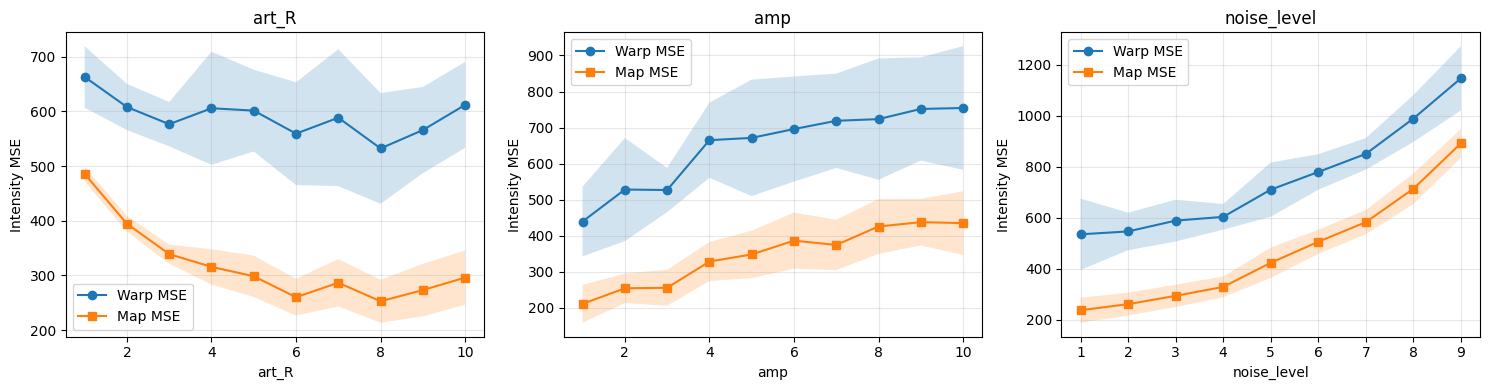

In [6]:
import numpy as np
import matplotlib.pyplot as plt

valid_groups = [g for g in experiment_groups if g in processed_results]
n_groups = len(valid_groups)

plt.figure(figsize=(5 * n_groups, 4))

for i, group in enumerate(valid_groups, 1):
    data = processed_results[group]

    x = np.array(data['labels'], dtype=float)
    avg_warp = np.array(data['avg_mse_warp'], dtype=float)
    std_warp = np.array(data['std_mse_warp'], dtype=float)
    avg_map = np.array(data['avg_mse_map'], dtype=float)
    std_map = np.array(data['std_mse_map'], dtype=float)

    plt.subplot(1, n_groups, i)

    plt.plot(x, avg_warp, marker='o', label='Warp MSE')
    plt.fill_between(x, avg_warp - std_warp, avg_warp + std_warp, alpha=0.2)

    plt.plot(x, avg_map, marker='s', label='Map MSE')
    plt.fill_between(x, avg_map - std_map, avg_map + std_map, alpha=0.2)

    plt.xlabel(group)
    plt.ylabel("Intensity MSE")
    plt.title(group)
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()